In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:\PADHAYI\Project\Churn Analysis\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [7]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# Replace spaces with NaN
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)

# Check how many NaNs now
print(df['TotalCharges'].isnull().sum())


11


In [9]:
# Convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [10]:
print(df['TotalCharges'].isnull().sum())

11


In [11]:
df.dropna(subset=['TotalCharges'], inplace=True)
df.reset_index(drop=True, inplace=True)

In [12]:
# Check new shape
print(df.shape)

(7032, 21)


In [13]:
df.drop('customerID', axis=1, inplace=True)
print(df.shape)

(7032, 20)


In [14]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(cat_cols)


['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [15]:
# Explore each categorical column to see number of unique values and the actual categories
# This helps identify typos, inconsistent values, or extra spaces before we proceed to cleaning.

for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].unique())
    print("-" * 50)


gender: 2 unique values
['Female' 'Male']
--------------------------------------------------
Partner: 2 unique values
['Yes' 'No']
--------------------------------------------------
Dependents: 2 unique values
['No' 'Yes']
--------------------------------------------------
PhoneService: 2 unique values
['No' 'Yes']
--------------------------------------------------
MultipleLines: 3 unique values
['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService: 3 unique values
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity: 3 unique values
['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup: 3 unique values
['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection: 3 unique values
['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport: 3 unique values
['No' 'Yes' 'No internet

In [16]:
# Step 4: Clean categorical columns by removing spaces and standardizing case
df[cat_cols] = df[cat_cols].apply(lambda x: x.str.strip())  # remove spaces
df[cat_cols] = df[cat_cols].apply(lambda x: x.str.title())  # make first letter uppercase for consistency

# Check cleaned categories again
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")
    print("-" * 50)


gender: ['Female' 'Male']
--------------------------------------------------
Partner: ['Yes' 'No']
--------------------------------------------------
Dependents: ['No' 'Yes']
--------------------------------------------------
PhoneService: ['No' 'Yes']
--------------------------------------------------
MultipleLines: ['No Phone Service' 'No' 'Yes']
--------------------------------------------------
InternetService: ['Dsl' 'Fiber Optic' 'No']
--------------------------------------------------
OnlineSecurity: ['No' 'Yes' 'No Internet Service']
--------------------------------------------------
OnlineBackup: ['Yes' 'No' 'No Internet Service']
--------------------------------------------------
DeviceProtection: ['No' 'Yes' 'No Internet Service']
--------------------------------------------------
TechSupport: ['No' 'Yes' 'No Internet Service']
--------------------------------------------------
StreamingTV: ['No' 'Yes' 'No Internet Service']
--------------------------------------------------

In [17]:
# Replace 'No internet service' and 'No phone service' with 'No'
# This ensures that these features remain binary ('Yes'/'No')

replace_cols = [
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in replace_cols:
    df[col] = df[col].replace({'No Internet Service': 'No', 'No Phone Service': 'No'})




In [18]:
# Verify replacement
for col in replace_cols:
    print(f"{col}: {df[col].unique()}")

MultipleLines: ['No' 'Yes']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']


In [19]:
# Step A: show which columns are numeric and which are object (text/categorical)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
obj_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:\n", num_cols)
print("\nObject (categorical/text) columns:\n", obj_cols)


Numeric columns:
 ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Object (categorical/text) columns:
 ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [20]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [21]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [22]:
# Generate summary statistics for all columns
# This gives us a quick overview of numeric distributions and categorical counts
df.describe(include='all').transpose()


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,7032,2,Male,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7032.0,NaN,NaN,NaN,0.1624,0.368844,0.0,0.0,0.0,0.0,1.0
Partner,7032,2,No,3639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7032,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7032.0,NaN,NaN,NaN,32.421786,24.54526,1.0,9.0,29.0,55.0,72.0
PhoneService,7032,2,Yes,6352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7032,2,No,4065,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7032,3,Fiber Optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7032,2,No,5017,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineBackup,7032,2,No,4607,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# View value counts for categorical columns
# This helps us understand category distribution and spot data issues
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())



gender value counts:
gender
Male      3549
Female    3483
Name: count, dtype: int64

Partner value counts:
Partner
No     3639
Yes    3393
Name: count, dtype: int64

Dependents value counts:
Dependents
No     4933
Yes    2099
Name: count, dtype: int64

PhoneService value counts:
PhoneService
Yes    6352
No      680
Name: count, dtype: int64

MultipleLines value counts:
MultipleLines
No     4065
Yes    2967
Name: count, dtype: int64

InternetService value counts:
InternetService
Fiber Optic    3096
Dsl            2416
No             1520
Name: count, dtype: int64

OnlineSecurity value counts:
OnlineSecurity
No     5017
Yes    2015
Name: count, dtype: int64

OnlineBackup value counts:
OnlineBackup
No     4607
Yes    2425
Name: count, dtype: int64

DeviceProtection value counts:
DeviceProtection
No     4614
Yes    2418
Name: count, dtype: int64

TechSupport value counts:
TechSupport
No     4992
Yes    2040
Name: count, dtype: int64

StreamingTV value counts:
StreamingTV
No     4329
Yes  

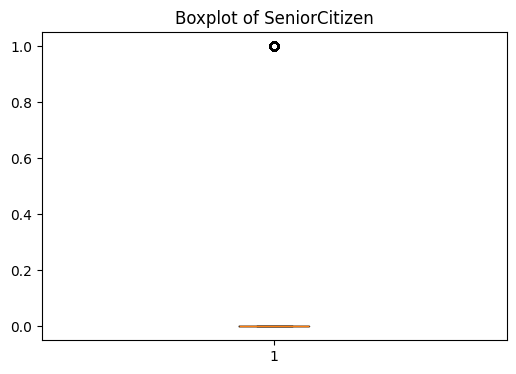

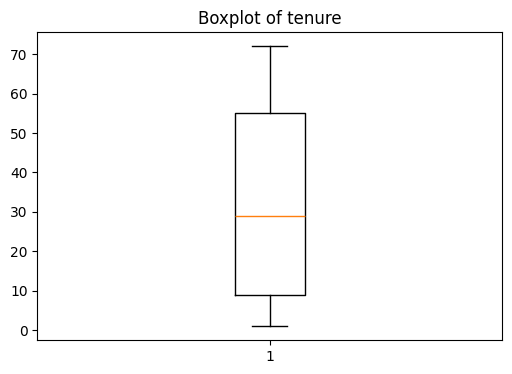

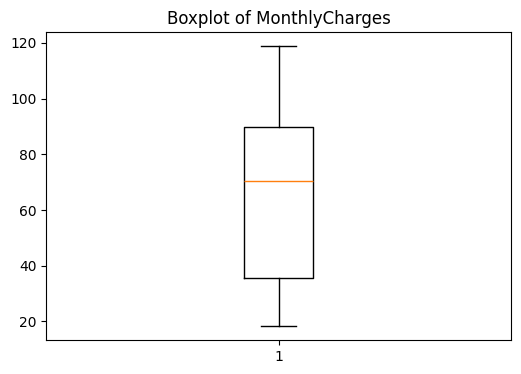

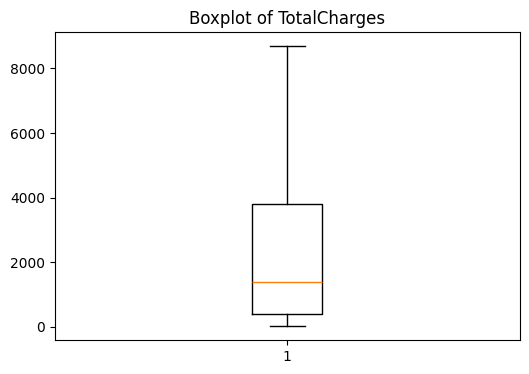

In [24]:
# check numeric columns for summary and spot outliers


num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


In [25]:

# Binary categorical variables (Yes/No, Male/Female) → label encode (map to 0/1)
# Multi-class categorical variables (more than 2 unique values) → one-hot encode



# 1. Identify binary categorical columns
binary_cols = [col for col in cat_cols if df[col].nunique() == 2]

# Map 'Yes'/'No' to 1/0, 'Male'/'Female' to 1/0, etc.
for col in binary_cols:
    df[col] = df[col].map({df[col].unique()[0]: 0, df[col].unique()[1]: 1})

# 2. One-hot encode multi-class categorical columns
multi_class_cols = [col for col in cat_cols if df[col].nunique() > 2]
df = pd.get_dummies(df, columns=multi_class_cols, drop_first=True)




In [26]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber Optic,InternetService_No,Contract_One Year,Contract_Two Year,PaymentMethod_Credit Card (Automatic),PaymentMethod_Electronic Check,PaymentMethod_Mailed Check
0,0,0,0,0,1,0,0,0,0,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,1,0,34,1,0,1,1,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,1,0,2,1,0,1,0,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,1,0,45,0,0,1,1,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,1,0,2,1,0,0,1,0,...,70.70,151.65,1,True,False,False,False,False,True,False


In [27]:
# Convert only boolean columns to integers
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)


In [28]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber Optic,InternetService_No,Contract_One Year,Contract_Two Year,PaymentMethod_Credit Card (Automatic),PaymentMethod_Electronic Check,PaymentMethod_Mailed Check
0,0,0,0,0,1,0,0,0,0,0,...,29.85,29.85,0,0,0,0,0,0,1,0
1,1,0,1,0,34,1,0,1,1,1,...,56.95,1889.50,0,0,0,1,0,0,0,1
2,1,0,1,0,2,1,0,1,0,0,...,53.85,108.15,1,0,0,0,0,0,0,1
3,1,0,1,0,45,0,0,1,1,1,...,42.30,1840.75,0,0,0,1,0,0,0,0
4,0,0,1,0,2,1,0,0,1,0,...,70.70,151.65,1,1,0,0,0,0,1,0


EDA

Churn counts:
 Churn
0    5163
1    1869
Name: count, dtype: int64

Churn percentage:
 Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\2199223147.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_counts.index, y=churn_counts.values, palette='viridis')


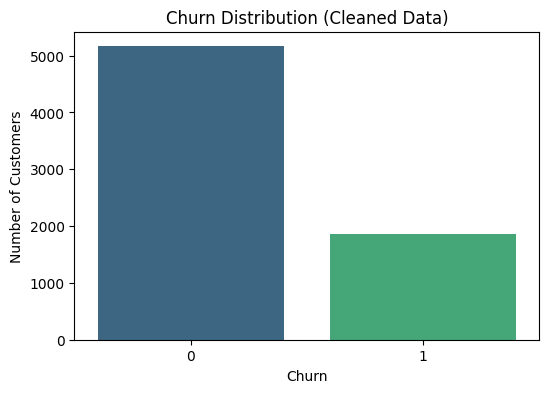

In [29]:
# Target variable distribution in cleaned dataset
# Count values of Churn
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

print("Churn counts:\n", churn_counts)
print("\nChurn percentage:\n", churn_percent)

# Plot
plt.figure(figsize=(6,4))
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette='viridis')
plt.title("Churn Distribution (Cleaned Data)")
plt.ylabel("Number of Customers")
plt.xlabel("Churn")
plt.show()


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\2494431415.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='Set2')


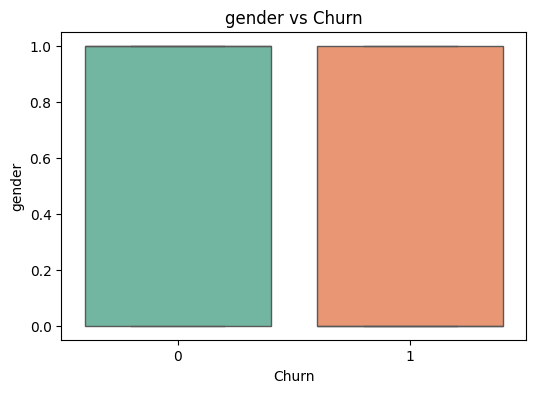

C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\2494431415.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='Set2')


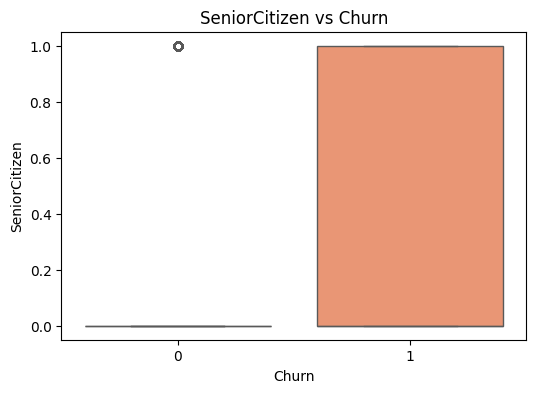

C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\2494431415.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='Set2')


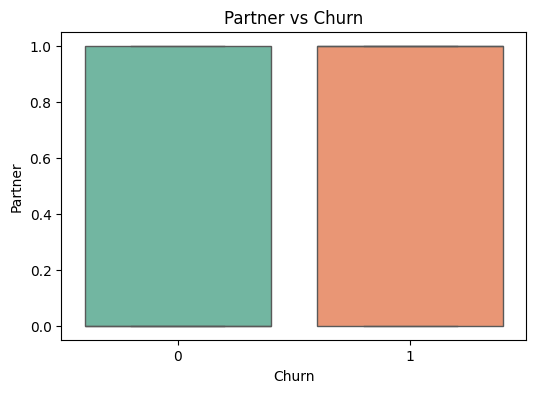

C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\2494431415.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='Set2')


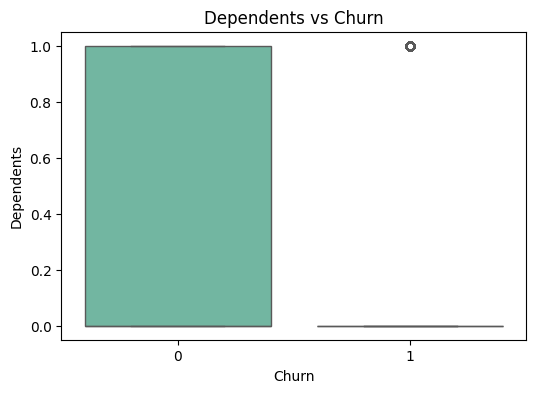

C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\2494431415.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='Set2')


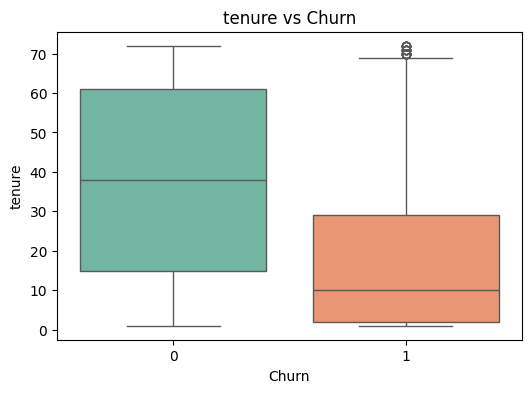

C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\2494431415.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='Set2')


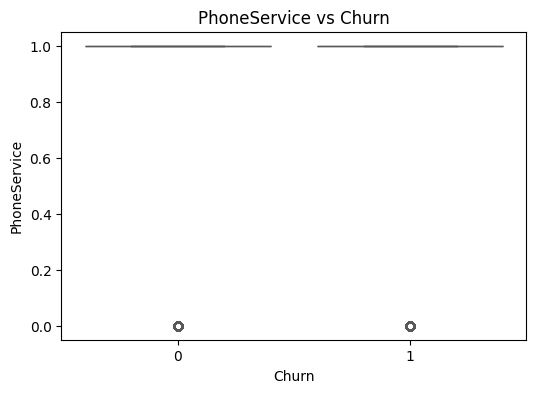

C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\2494431415.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='Set2')


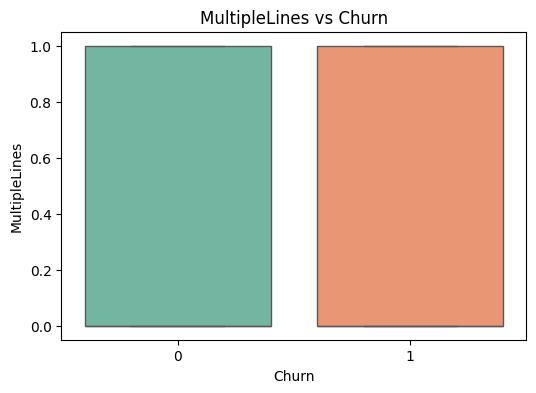

C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\2494431415.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='Set2')


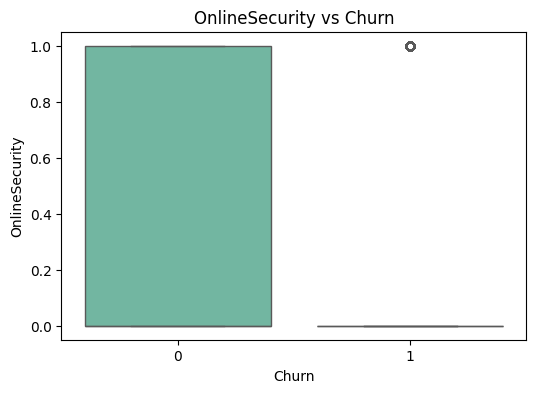

C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\2494431415.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='Set2')


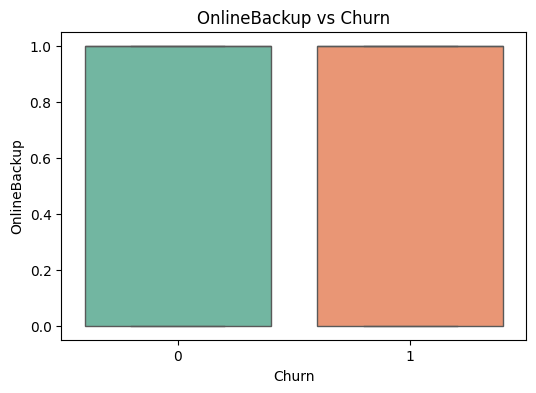

C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\2494431415.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='Set2')


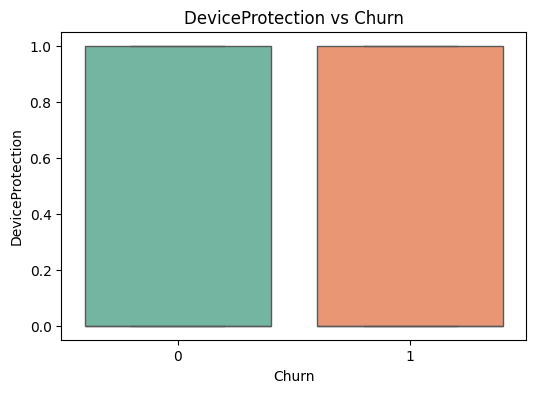

C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\2494431415.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='Set2')


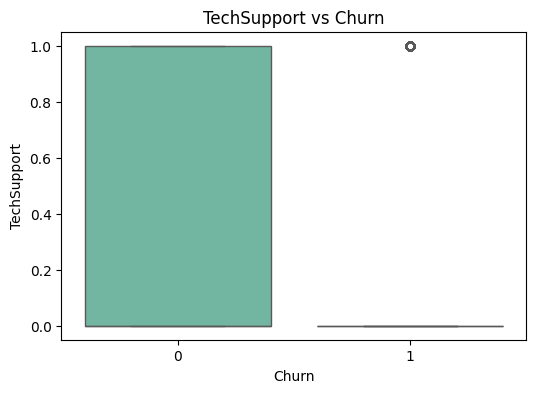

C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\2494431415.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='Set2')


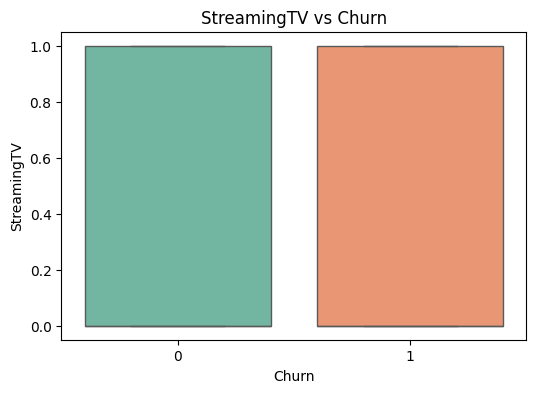

C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\2494431415.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='Set2')


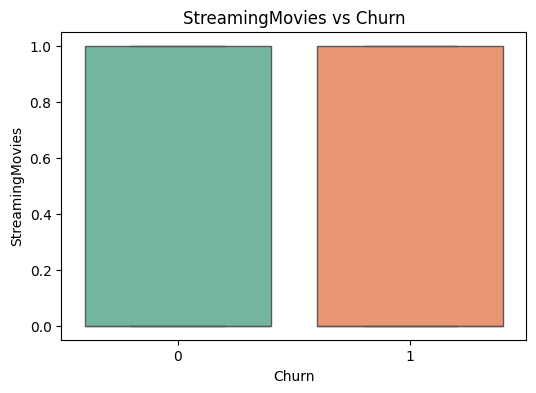

C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\2494431415.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='Set2')


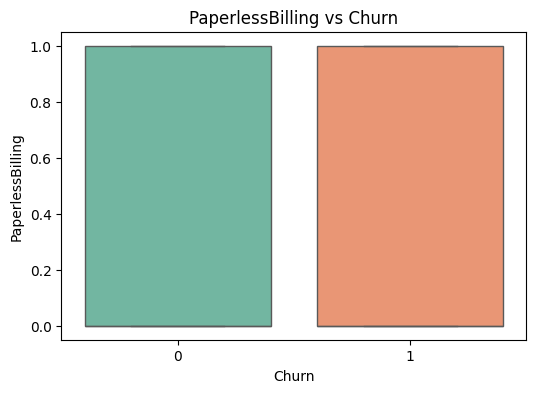

C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\2494431415.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='Set2')


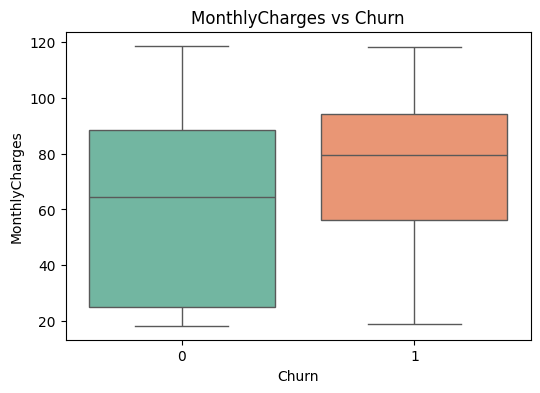

C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\2494431415.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='Set2')


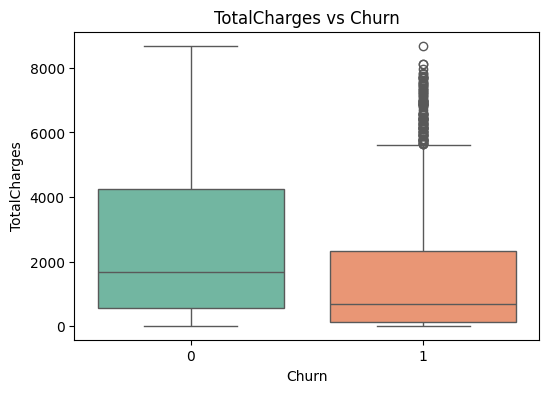

In [30]:
# Numerical features vs Churn
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('Churn')  # exclude target

import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Churn', y=col, data=df, palette='Set2')
    plt.title(f"{col} vs Churn")
    plt.show()


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\3351495987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df, palette='viridis')



Churn rate by gender:
gender
0    26.959518
1    26.204565
Name: Churn, dtype: float64


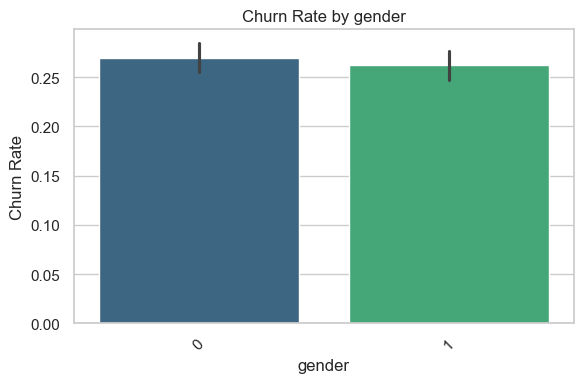


Churn rate by SeniorCitizen:
SeniorCitizen
0    23.650255
1    41.681261
Name: Churn, dtype: float64


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\3351495987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df, palette='viridis')


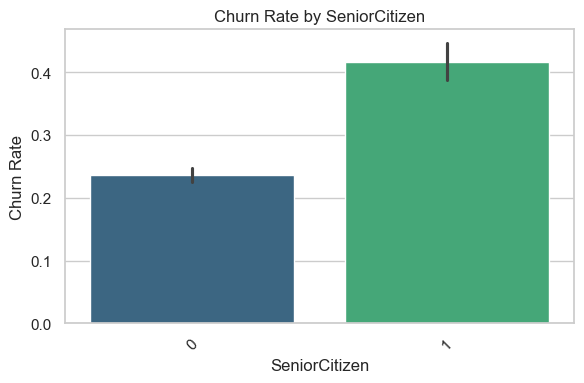


Churn rate by Partner:
Partner
0    19.717065
1    32.976092
Name: Churn, dtype: float64


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\3351495987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df, palette='viridis')


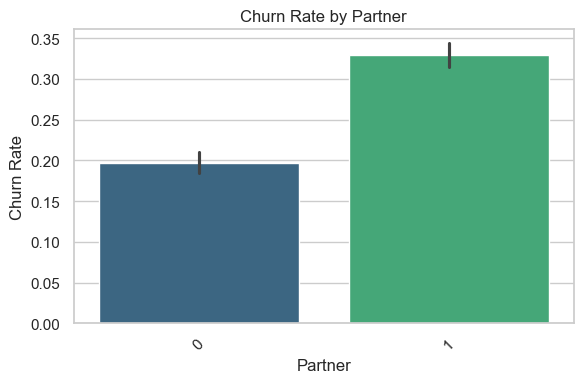


Churn rate by Dependents:
Dependents
0    31.279140
1    15.531205
Name: Churn, dtype: float64


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\3351495987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df, palette='viridis')


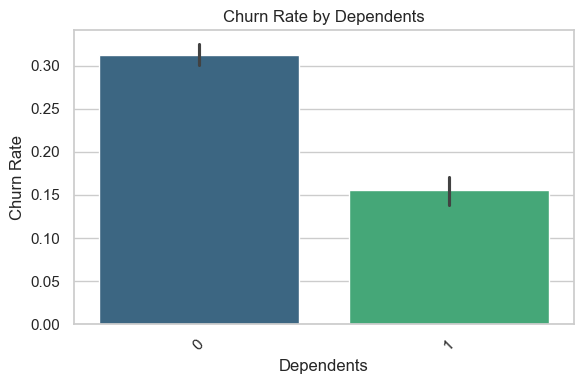


Churn rate by PhoneService:
PhoneService
0    25.000000
1    26.747481
Name: Churn, dtype: float64


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\3351495987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df, palette='viridis')


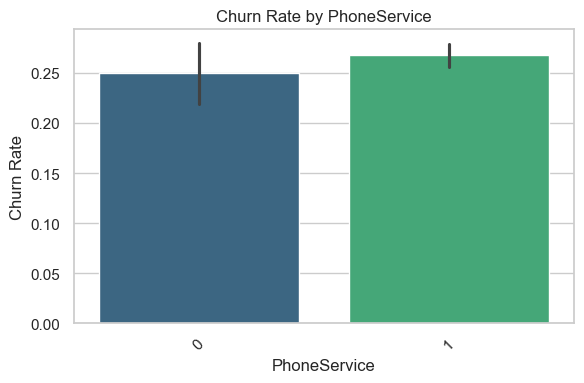


Churn rate by MultipleLines:
MultipleLines
0    25.067651
1    28.648466
Name: Churn, dtype: float64


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\3351495987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df, palette='viridis')


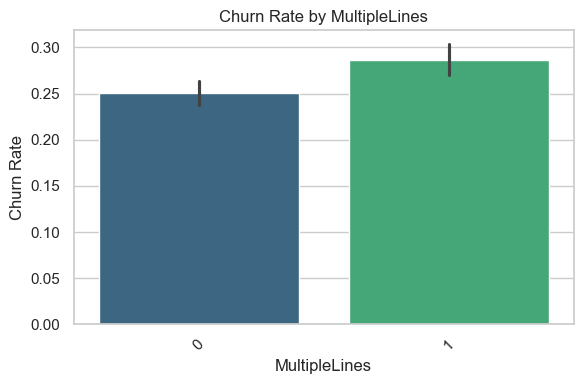


Churn rate by OnlineSecurity:
OnlineSecurity
0    31.373331
1    14.640199
Name: Churn, dtype: float64


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\3351495987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df, palette='viridis')


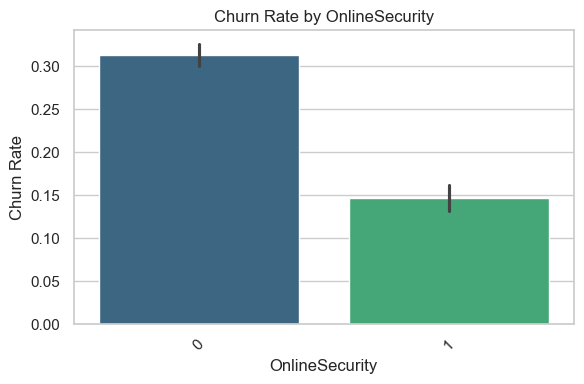


Churn rate by OnlineBackup:
OnlineBackup
0    21.56701
1    29.21641
Name: Churn, dtype: float64


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\3351495987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df, palette='viridis')


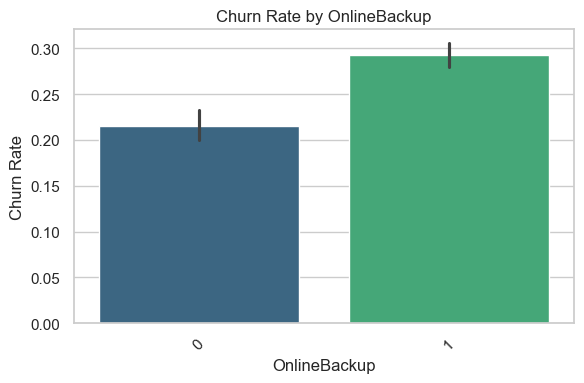


Churn rate by DeviceProtection:
DeviceProtection
0    28.695275
1    22.539289
Name: Churn, dtype: float64


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\3351495987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df, palette='viridis')


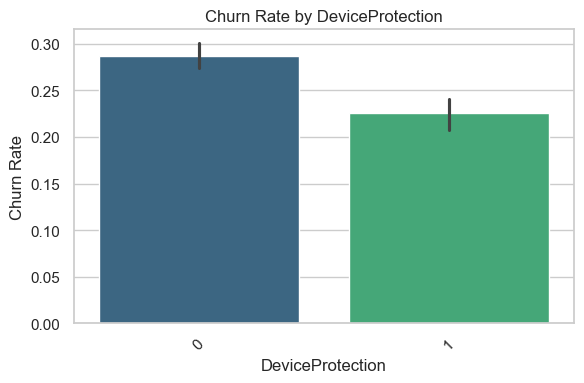


Churn rate by TechSupport:
TechSupport
0    31.229968
1    15.196078
Name: Churn, dtype: float64


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\3351495987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df, palette='viridis')


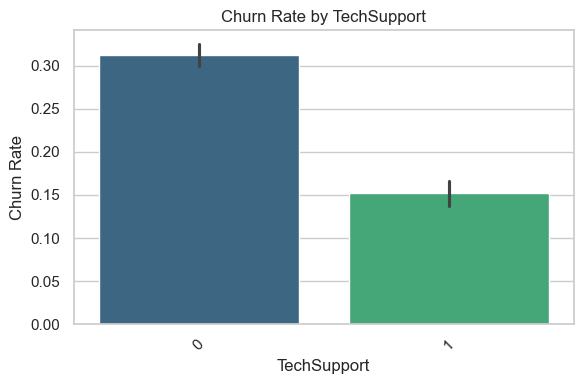


Churn rate by StreamingTV:
StreamingTV
0    24.370524
1    30.114687
Name: Churn, dtype: float64


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\3351495987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df, palette='viridis')


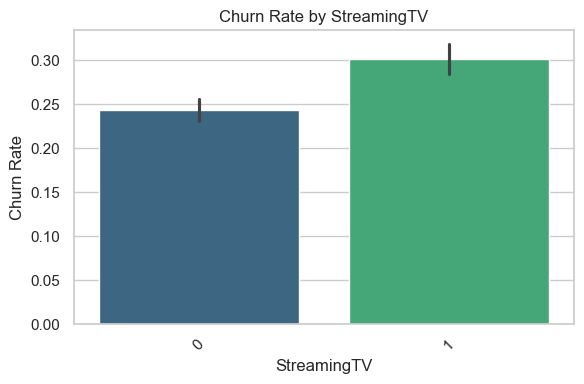


Churn rate by StreamingMovies:
StreamingMovies
0    24.436178
1    29.952398
Name: Churn, dtype: float64


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\3351495987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df, palette='viridis')


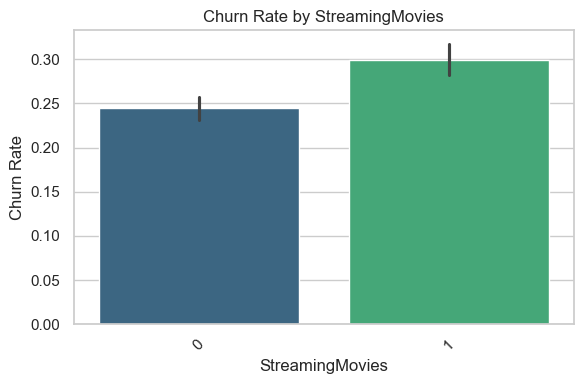

C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\3351495987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df, palette='viridis')



Churn rate by PaperlessBilling:
PaperlessBilling
0    33.589251
1    16.375698
Name: Churn, dtype: float64


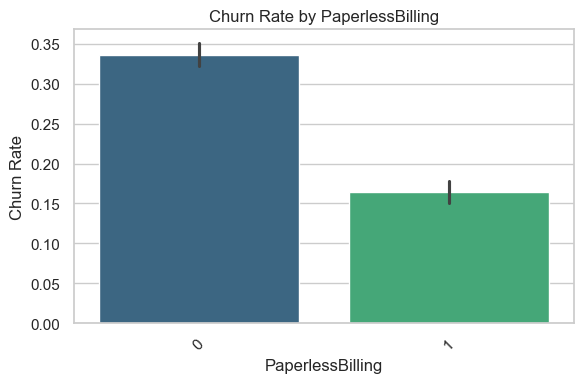


Churn rate by InternetService_Fiber Optic:
InternetService_Fiber Optic
0    14.532520
1    41.892765
Name: Churn, dtype: float64


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\3351495987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df, palette='viridis')


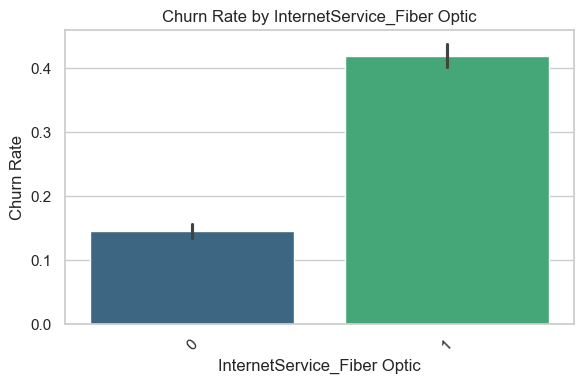


Churn rate by InternetService_No:
InternetService_No
0    31.857765
1     7.434211
Name: Churn, dtype: float64


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\3351495987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df, palette='viridis')


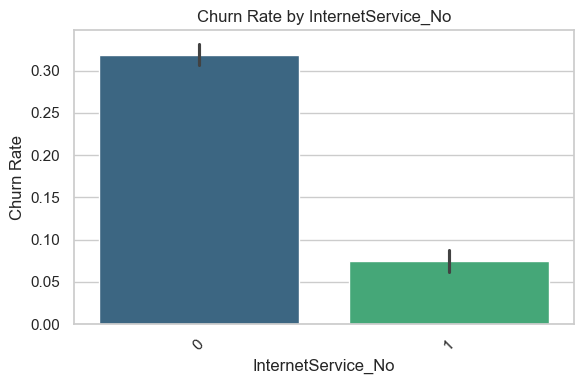


Churn rate by Contract_One Year:
Contract_One Year
0    30.629496
1    11.277174
Name: Churn, dtype: float64


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\3351495987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df, palette='viridis')


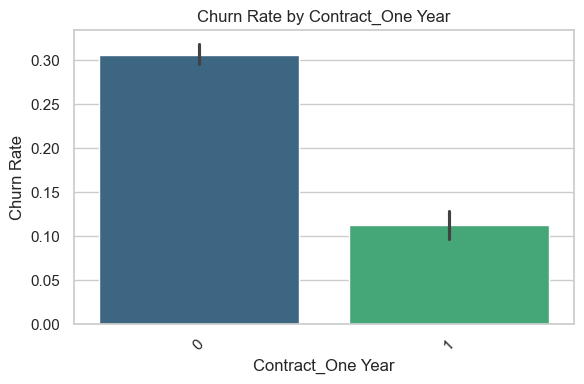


Churn rate by Contract_Two Year:
Contract_Two Year
0    34.056480
1     2.848665
Name: Churn, dtype: float64


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\3351495987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df, palette='viridis')


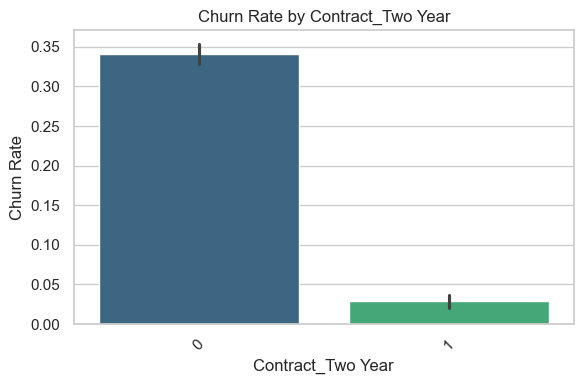

C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\3351495987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df, palette='viridis')



Churn rate by PaymentMethod_Credit Card (Automatic):
PaymentMethod_Credit Card (Automatic)
0    29.704228
1    15.253123
Name: Churn, dtype: float64


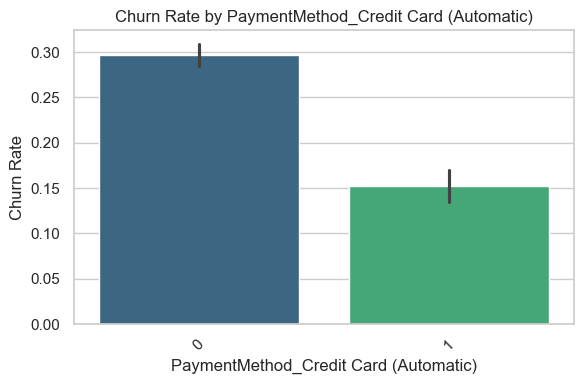


Churn rate by PaymentMethod_Electronic Check:
PaymentMethod_Electronic Check
0    17.098779
1    45.285412
Name: Churn, dtype: float64


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\3351495987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df, palette='viridis')


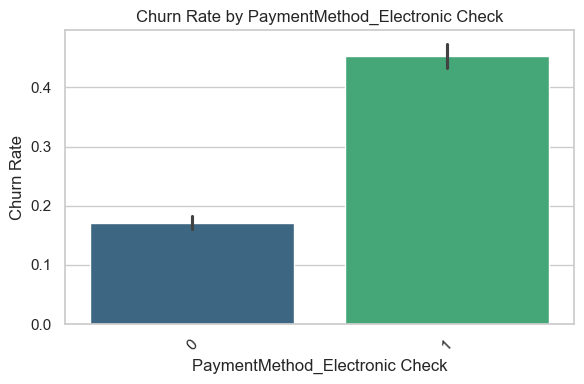


Churn rate by PaymentMethod_Mailed Check:
PaymentMethod_Mailed Check
0    28.758290
1    19.201995
Name: Churn, dtype: float64


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\3351495987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df, palette='viridis')


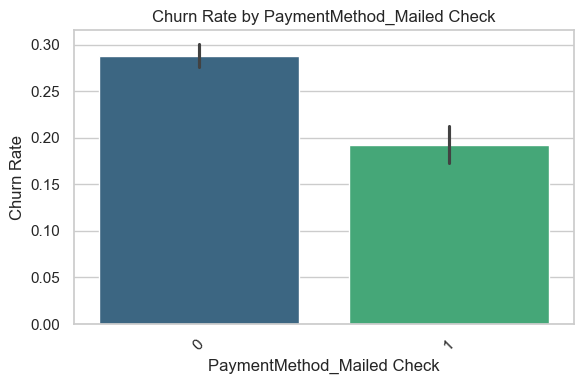

In [31]:
# Relationship between categorical variables and Churn

# Set up plot style
sns.set(style="whitegrid")

# List of categorical columns (excluding target 'Churn')
binary_cols_encoded = [col for col in df.columns if col != 'Churn' and df[col].nunique() == 2]

for col in binary_cols_encoded:
    plt.figure(figsize=(6,4))
    
    # Calculate churn rates per category
    churn_rate = df.groupby(col)['Churn'].mean() * 100 # percentage of churned customers
    print(f"\nChurn rate by {col}:")
    print(churn_rate)
    
    # Plot
    sns.barplot(x=col, y='Churn', data=df, palette='viridis')
    plt.title(f'Churn Rate by {col}')
    plt.ylabel('Churn Rate')
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



--- tenure ---
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
0      5163.0  37.650010  24.076940  1.0  15.0  38.0  61.0  72.0
1      1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\588523427.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='viridis')


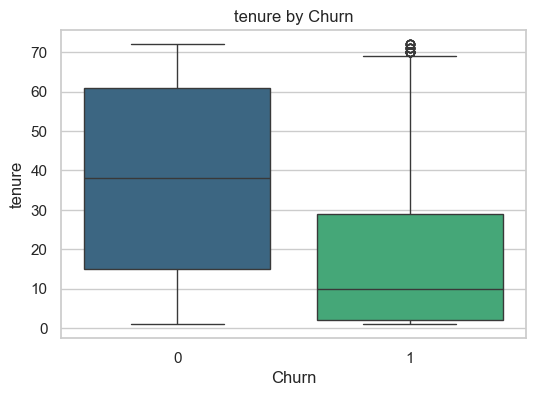


--- MonthlyCharges ---
        count       mean        std    min    25%    50%     75%     max
Churn                                                                   
0      5163.0  61.307408  31.094557  18.25  25.10  64.45  88.475  118.75
1      1869.0  74.441332  24.666053  18.85  56.15  79.65  94.200  118.35


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\588523427.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='viridis')


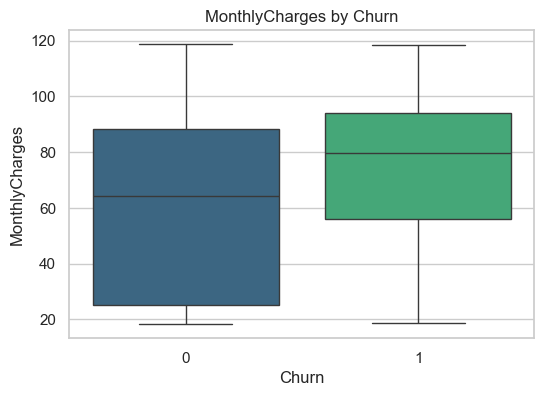


--- TotalCharges ---
        count         mean          std    min      25%      50%       75%  \
Churn                                                                        
0      5163.0  2555.344141  2329.456984  18.80  577.825  1683.60  4264.125   
1      1869.0  1531.796094  1890.822994  18.85  134.500   703.55  2331.300   

           max  
Churn           
0      8672.45  
1      8684.80  


C:\Users\ankit\AppData\Local\Temp\ipykernel_8224\588523427.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='viridis')


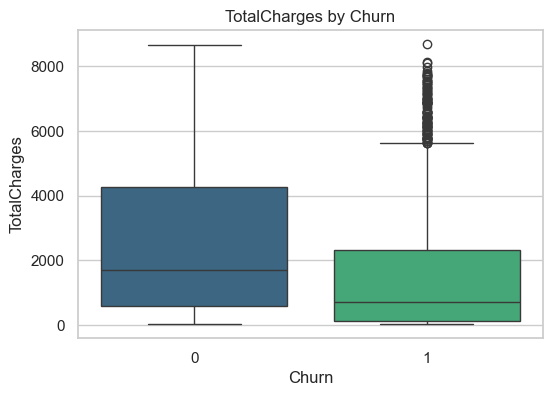

In [32]:

# Numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Loop through each numerical column
for col in num_cols:
    print(f"\n--- {col} ---")
    print(df.groupby('Churn')[col].describe())  # Summary stats by churn

    # Plot boxplot
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Churn', y=col, data=df, palette='viridis')
    plt.title(f'{col} by Churn')
    plt.show()


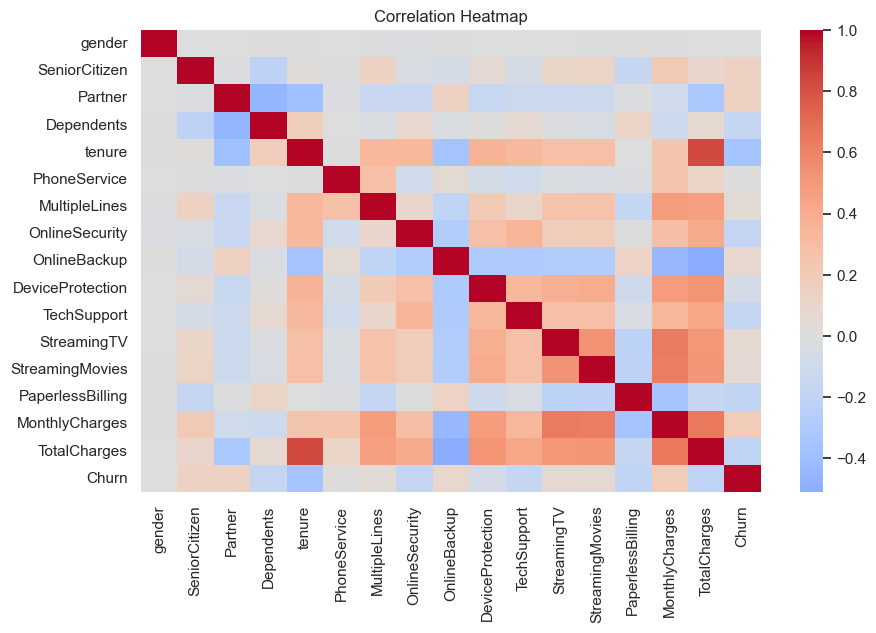


Correlation of features with Churn:
Churn               1.000000
MonthlyCharges      0.192922
SeniorCitizen       0.150541
Partner             0.149982
OnlineBackup        0.082307
StreamingTV         0.063254
StreamingMovies     0.060860
MultipleLines       0.040033
PhoneService        0.011691
gender             -0.008545
DeviceProtection   -0.066193
Dependents         -0.163128
TechSupport        -0.164716
OnlineSecurity     -0.171270
PaperlessBilling   -0.191454
TotalCharges       -0.199485
tenure             -0.354049
Name: Churn, dtype: float64


In [33]:
# Correlation Analysis


# 1. Select numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64', 'bool'])  # bool because we encoded True/False
numeric_df = numeric_df.astype(int)  # convert booleans to int for correlation

# 2. Compute correlation matrix
corr_matrix = numeric_df.corr()

# 3. Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

# 4. Show correlation of each variable with Churn
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)
print("\nCorrelation of features with Churn:")
print(churn_corr)


In [34]:
#  Find highly correlated pairs (abs corr > 0.8)

# numeric columns only (exclude target)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Churn' in num_cols:
    num_cols.remove('Churn')

corr = df[num_cols].corr().abs()

# Show pairs with correlation > 0.8
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = []
threshold = 0.8
for col in upper.columns:
    for row in upper.index:
        val = upper.loc[row, col]
        if pd.notna(val) and val > threshold:
            high_corr.append((row, col, val))

print("Highly correlated pairs (abs corr > 0.8):")
if high_corr:
    for r, c, v in high_corr:
        print(f"{r}  <->  {c}  :  {v:.3f}")
else:
    print("None found (no abs corr > 0.8).")

# Also print the correlation of known suspects for quick view
print("\nQuick correlations of suspects:")
print(corr[['tenure','MonthlyCharges','TotalCharges']].loc[['tenure','MonthlyCharges','TotalCharges']])


Highly correlated pairs (abs corr > 0.8):
tenure  <->  TotalCharges  :  0.826

Quick correlations of suspects:
                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.246862      0.825880
MonthlyCharges  0.246862        1.000000      0.651065
TotalCharges    0.825880        0.651065      1.000000


In [35]:
# Drop TotalCharges to avoid multicollinearity
df = df.drop(columns=['TotalCharges'])

print("Columns after dropping TotalCharges:")
print(df.columns)


Columns after dropping TotalCharges:
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'Churn',
       'InternetService_Fiber Optic', 'InternetService_No',
       'Contract_One Year', 'Contract_Two Year',
       'PaymentMethod_Credit Card (Automatic)',
       'PaymentMethod_Electronic Check', 'PaymentMethod_Mailed Check'],
      dtype='object')


In [36]:
from sklearn.model_selection import train_test_split

# Separate target and features
X = df.drop(columns=['Churn'])
y = df['Churn']

# Train/test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (5625, 22)
Test shape: (1407, 22)


In [37]:
# for models like logistic regression and SVM
from sklearn.preprocessing import StandardScaler

# Identify numeric columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Initialize scaler
scaler = StandardScaler()

# Fit on train and transform both train/test
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [38]:
# We ensure everything is numeric so that sklearn models won’t break.
X_train = X_train.astype(float)
X_test = X_test.astype(float)


In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Initialize model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Fit on training data
log_reg.fit(X_train, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [40]:
# Predictions
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]  # probabilities for ROC-AUC


In [41]:
# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# Full classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8038379530916845
Precision: 0.6467065868263473
Recall: 0.5775401069518716
F1 Score: 0.6101694915254238
ROC-AUC: 0.8337392776348416

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.58      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Confusion Matrix:
 [[915 118]
 [158 216]]


In [42]:
!pip install imbalanced-learn



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import pandas as pd

# Function to train, predict, and evaluate
def evaluate_model(model, X_train, y_train, X_test, y_test, desc):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        'Model': desc,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

results = []

# 1️⃣ Baseline Logistic Regression
log_reg_base = LogisticRegression(max_iter=1000, random_state=42)
results.append(evaluate_model(log_reg_base, X_train, y_train, X_test, y_test, "Baseline"))

# 2️⃣ Class Weight Balanced
log_reg_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
results.append(evaluate_model(log_reg_bal, X_train, y_train, X_test, y_test, "Class Weight Balanced"))

# 3️⃣ SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)
results.append(evaluate_model(log_reg_smote, X_train_sm, y_train_sm, X_test, y_test, "SMOTE"))

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print(results_df)


                   Model  Accuracy  Precision    Recall        F1   ROC-AUC
0               Baseline  0.803838   0.646707  0.577540  0.610169  0.833739
1  Class Weight Balanced  0.727790   0.492437  0.783422  0.604747  0.833100
2                  SMOTE  0.734897   0.500879  0.762032  0.604454  0.832787


In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Function to train, predict, and evaluate models
def evaluate_model(model, X_train, y_train, X_test, y_test, desc):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        "Model": desc,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred)
    }

# List of models to test
models = [
    (LogisticRegression(max_iter=1000, random_state=42), "Logistic Regression"),
    (DecisionTreeClassifier(random_state=42), "Decision Tree"),
    (RandomForestClassifier(random_state=42), "Random Forest"),
    (GradientBoostingClassifier(random_state=42), "Gradient Boosting"
   )
]

# Run evaluation
results = []
for clf, name in models:
    results.append(evaluate_model(clf, X_train, y_train, X_test, y_test, name))

# Show results in a dataframe
df_results = pd.DataFrame(results)
print(df_results.sort_values(by="F1", ascending=False))


                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression  0.803838   0.646707  0.577540  0.610169  0.731655
3    Gradient Boosting  0.793888   0.634615  0.529412  0.577259  0.709527
2        Random Forest  0.780384   0.607261  0.491979  0.543575  0.688390
1        Decision Tree  0.719261   0.474699  0.526738  0.499366  0.657851


In [45]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())


Before SMOTE: {0: 4130, 1: 1495}
After SMOTE: {0: 4130, 1: 4130}


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Store results
results = []

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)  # SMOTE-balanced training data
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred_proba)
    })

# Convert to DataFrame and sort by F1 Score
results_df_smote = pd.DataFrame(results).sort_values(by="F1", ascending=False)

print(results_df_smote)


                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
3    Gradient Boosting  0.771855   0.557235  0.689840  0.616487  0.834379
0  Logistic Regression  0.734897   0.500879  0.762032  0.604454  0.832787
2        Random Forest  0.773276   0.574124  0.569519  0.571812  0.811373
1        Decision Tree  0.722814   0.481132  0.545455  0.511278  0.665801


In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# ----------------------------
# 1️⃣ Logistic Regression (Baseline) Tuning
# ----------------------------
log_reg = LogisticRegression(max_iter=1000, random_state=42)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],  # Regularization strength
    'solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(log_reg, param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)

print("🔹 Logistic Regression Best Params:", grid_lr.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, best_lr.predict_proba(X_test)[:, 1]))


# ----------------------------
# 2️⃣ Gradient Boosting (SMOTE) Tuning
# ----------------------------
gb = GradientBoostingClassifier(random_state=42)

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid_gb = GridSearchCV(gb, param_grid_gb, cv=5, scoring='f1', n_jobs=-1)
grid_gb.fit(X_train_smote, y_train_smote)  # SMOTE data

best_gb = grid_gb.best_estimator_
y_pred_gb = best_gb.predict(X_test)

print("\n🔹 Gradient Boosting Best Params:", grid_gb.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1:", f1_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, best_gb.predict_proba(X_test)[:, 1]))


🔹 Logistic Regression Best Params: {'C': 1, 'solver': 'liblinear'}
Accuracy: 0.8038379530916845
Precision: 0.6467065868263473
Recall: 0.5775401069518716
F1: 0.6101694915254238
ROC-AUC: 0.8337573962965457

🔹 Gradient Boosting Best Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
Accuracy: 0.7746979388770433
Precision: 0.5640449438202247
Recall: 0.6711229946524064
F1: 0.612942612942613
ROC-AUC: 0.8336253889041315


In [49]:
import joblib
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import GradientBoostingClassifier

# ==== 1. Prepare full data ====
# We already have X_train, X_test, y_train, y_test from before
# Combine them to use the full dataset
X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

# ==== 2. Apply SMOTE on full dataset ====
smote = SMOTE(random_state=42)
X_full_smote, y_full_smote = smote.fit_resample(X_full, y_full)

# ==== 3. Retrain Gradient Boosting with best params ====
final_gb = GradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=5,
    n_estimators=100,
    random_state=42
)
final_gb.fit(X_full_smote, y_full_smote)

feature_columns = X.columns.tolist()

# Save column order for later use

joblib.dump(feature_columns, "feature_columns.pkl")

# ==== 4. Save the model ====
joblib.dump(final_gb, "gradient_boosting_churn_model.pkl")

# ==== 5. (Optional) Save preprocessing steps if needed ====
# Example: joblib.dump(preprocessor, "preprocessor.pkl")

print("✅ Final Gradient Boosting (SMOTE) model trained and saved!")


✅ Final Gradient Boosting (SMOTE) model trained and saved!
